In [1]:
%pip -q install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: C:\Users\arnav\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def imshow_rgb(img_bgr, title=None):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


template shape: (219, 1557, 3)
input shape: (784, 2400, 3)


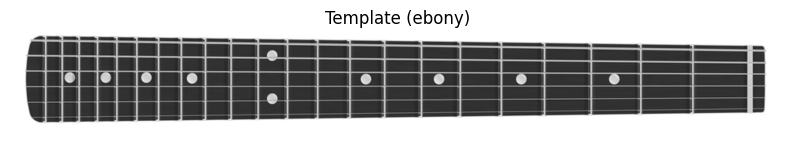

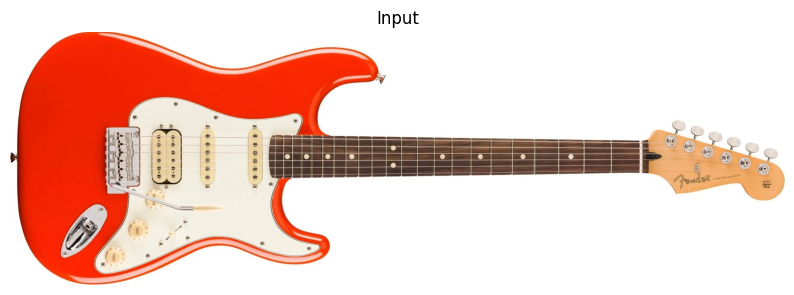

In [3]:
TEMPLATE_PATH = "ebony.png"
INPUT_PATH    = "input.png"

template = cv2.imread(TEMPLATE_PATH, cv2.IMREAD_COLOR)
inp      = cv2.imread(INPUT_PATH, cv2.IMREAD_COLOR)

if template is None:
    raise FileNotFoundError(f"Could not read template at: {TEMPLATE_PATH}")
if inp is None:
    raise FileNotFoundError(f"Could not read input at: {INPUT_PATH}")

print("template shape:", template.shape)
print("input shape:", inp.shape)

imshow_rgb(template, "Template (ebony)")
imshow_rgb(inp, "Input")


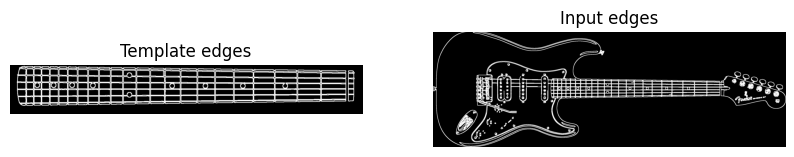

In [4]:
def preprocess_for_matching(img_bgr, blur_ksize=5):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    if blur_ksize and blur_ksize > 1:
        gray = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)
    edges = cv2.Canny(gray, 50, 150)
    edges = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=1)
    return edges

temp_proc = preprocess_for_matching(template)
inp_proc  = preprocess_for_matching(inp)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(temp_proc, cmap="gray"); plt.axis("off"); plt.title("Template edges")
plt.subplot(1,2,2); plt.imshow(inp_proc, cmap="gray");  plt.axis("off"); plt.title("Input edges")
plt.show()


In [5]:
def multiscale_match_template(
    img_proc,
    templ_proc,
    scales=None,
    method=cv2.TM_CCOEFF_NORMED,
    min_template_size=(40, 40),
):
    if scales is None:
        scales = np.linspace(0.35, 2.25, 40)

    best = {
        "score": -1.0,
        "scale": None,
        "top_left": None,
        "wh": None,
        "result_shape": None,
    }

    th, tw = templ_proc.shape[:2]
    for s in scales:
        new_w = int(round(tw * s))
        new_h = int(round(th * s))
        if new_w < min_template_size[0] or new_h < min_template_size[1]:
            continue
        if new_w >= img_proc.shape[1] or new_h >= img_proc.shape[0]:
            continue

        templ_resized = cv2.resize(templ_proc, (new_w, new_h), interpolation=cv2.INTER_AREA)
        res = cv2.matchTemplate(img_proc, templ_resized, method)

        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
        score = max_val if method in (cv2.TM_CCOEFF, cv2.TM_CCOEFF_NORMED,
                                      cv2.TM_CCORR, cv2.TM_CCORR_NORMED) else -min_val
        loc   = max_loc if method in (cv2.TM_CCOEFF, cv2.TM_CCOEFF_NORMED,
                                      cv2.TM_CCORR, cv2.TM_CCORR_NORMED) else min_loc

        if score > best["score"]:
            best.update(
                score=score,
                scale=float(s),
                top_left=loc,
                wh=(new_w, new_h),
                result_shape=res.shape,
            )

    if best["top_left"] is None:
        raise RuntimeError("No valid scales produced a match. Check image paths/sizes.")
    return best

best = multiscale_match_template(inp_proc, temp_proc)
best


{'score': 0.5753427743911743,
 'scale': 0.7397435897435898,
 'top_left': (882, 317),
 'wh': (1152, 162),
 'result_shape': (623, 1249)}

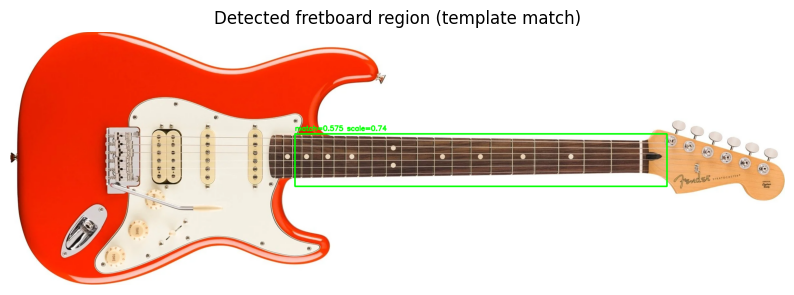

Best match score: 0.5753
Box: x=882, y=317, w=1152, h=162


In [6]:
x, y = best["top_left"]
w, h = best["wh"]
score = best["score"]

out = inp.copy()
cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 3)
cv2.putText(out, f"match={score:.3f} scale={best['scale']:.2f}", (x, max(25, y - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

imshow_rgb(out, "Detected fretboard region (template match)")
print(f"Best match score: {score:.4f}")
print(f"Box: x={x}, y={y}, w={w}, h={h}")


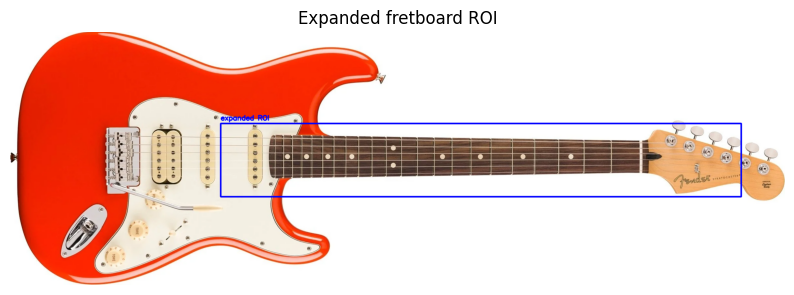

Expanded ROI: x0=652, y0=285, x1=2264, y1=511


In [7]:
def expand_box(x, y, w, h, img_w, img_h, pad_frac=0.15):
    pad_x = int(round(w * pad_frac))
    pad_y = int(round(h * pad_frac))
    x0 = max(0, x - pad_x)
    y0 = max(0, y - pad_y)
    x1 = min(img_w - 1, x + w + pad_x)
    y1 = min(img_h - 1, y + h + pad_y)
    return x0, y0, x1, y1

H, W = inp.shape[:2]
x0, y0, x1, y1 = expand_box(x, y, w, h, W, H, pad_frac=0.20)

out2 = inp.copy()
cv2.rectangle(out2, (x0, y0), (x1, y1), (255, 0, 0), 3)
cv2.putText(out2, "expanded ROI", (x0, max(25, y0 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2, cv2.LINE_AA)

imshow_rgb(out2, "Expanded fretboard ROI")
print(f"Expanded ROI: x0={x0}, y0={y0}, x1={x1}, y1={y1}")


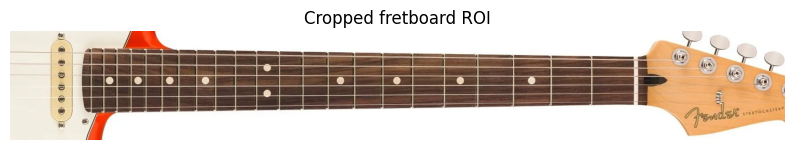

In [8]:
roi = inp[y0:y1, x0:x1].copy()
imshow_rgb(roi, "Cropped fretboard ROI")

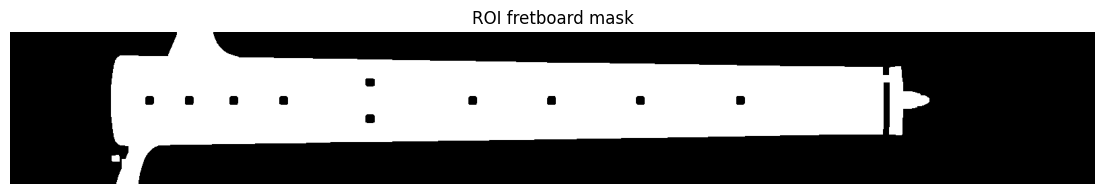

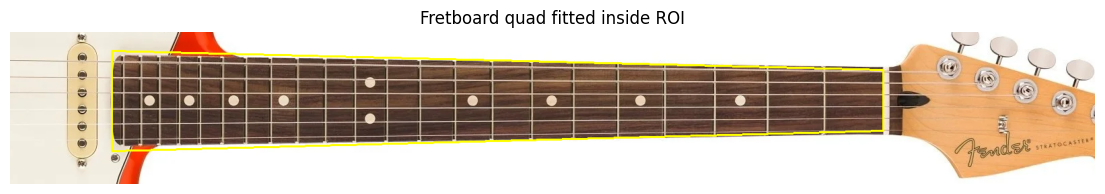

In [9]:

def build_fretboard_mask_from_roi(roi_bgr, gray_thresh=140):
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    mask = ((gray < gray_thresh).astype(np.uint8) * 255)

    k_close = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=1)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), connectivity=8)
    if num_labels <= 1:
        raise RuntimeError("Could not find a fretboard component inside the ROI.")

    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    fret_mask = ((labels == largest).astype(np.uint8) * 255)

    k_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    fret_mask = cv2.morphologyEx(fret_mask, cv2.MORPH_OPEN, k_open, iterations=1)
    return fret_mask


def longest_true_run(valid):
    best = None
    start = None
    for i, v in enumerate(valid):
        if v and start is None:
            start = i
        if start is not None and ((not v) or i == len(valid) - 1):
            end = i if (v and i == len(valid) - 1) else i - 1
            if best is None or (end - start) > (best[1] - best[0]):
                best = (start, end)
            start = None
    if best is None:
        raise RuntimeError("Could not find a valid fretboard span.")
    return best


def smooth_1d(arr, k=31):
    if k <= 1:
        return arr.copy()
    if k % 2 == 0:
        k += 1
    pad = k // 2
    arr_pad = np.pad(arr.astype(np.float32), (pad, pad), mode="edge")
    kernel = np.ones(k, dtype=np.float32) / k
    return np.convolve(arr_pad, kernel, mode="valid")


def fit_fretboard_quad_from_mask(mask):
    Hm, Wm = mask.shape
    mask_bool = mask > 0

    tops = np.full(Wm, np.nan, dtype=np.float32)
    bottoms = np.full(Wm, np.nan, dtype=np.float32)

    for xcol in range(Wm):
        ys = np.where(mask_bool[:, xcol])[0]
        if len(ys) > 0:
            tops[xcol] = ys.min()
            bottoms[xcol] = ys.max()

    valid = (~np.isnan(tops)) & (~np.isnan(bottoms)) & ((bottoms - tops) > 0.22 * Hm)
    x_left, x_right = longest_true_run(valid)

    xs = np.arange(x_left, x_right + 1, dtype=np.float32)
    top_vals = smooth_1d(tops[x_left:x_right + 1], k=31)
    bot_vals = smooth_1d(bottoms[x_left:x_right + 1], k=31)

    top_fit = np.polyfit(xs, top_vals, 1)
    bot_fit = np.polyfit(xs, bot_vals, 1)

    y_tl = np.polyval(top_fit, x_left)
    y_tr = np.polyval(top_fit, x_right)
    y_bl = np.polyval(bot_fit, x_left)
    y_br = np.polyval(bot_fit, x_right)

    quad = np.array([
        [x_left,  y_tl],
        [x_right, y_tr],
        [x_right, y_br],
        [x_left,  y_bl],
    ], dtype=np.float32)

    return quad, {
        "tops": tops,
        "bottoms": bottoms,
        "valid": valid,
        "x_left": x_left,
        "x_right": x_right,
        "top_fit": top_fit,
        "bot_fit": bot_fit,
    }


fret_mask = build_fretboard_mask_from_roi(roi)
quad_roi, quad_debug = fit_fretboard_quad_from_mask(fret_mask)

plt.figure(figsize=(14, 3))
plt.imshow(fret_mask, cmap="gray")
plt.axis("off")
plt.title("ROI fretboard mask")
plt.show()

roi_quad_vis = roi.copy()
quad_int = np.round(quad_roi).astype(np.int32)
cv2.polylines(roi_quad_vis, [quad_int.reshape(-1, 1, 2)], True, (0, 255, 255), 2)

plt.figure(figsize=(14, 3))
plt.imshow(cv2.cvtColor(roi_quad_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Fretboard quad fitted inside ROI")
plt.show()


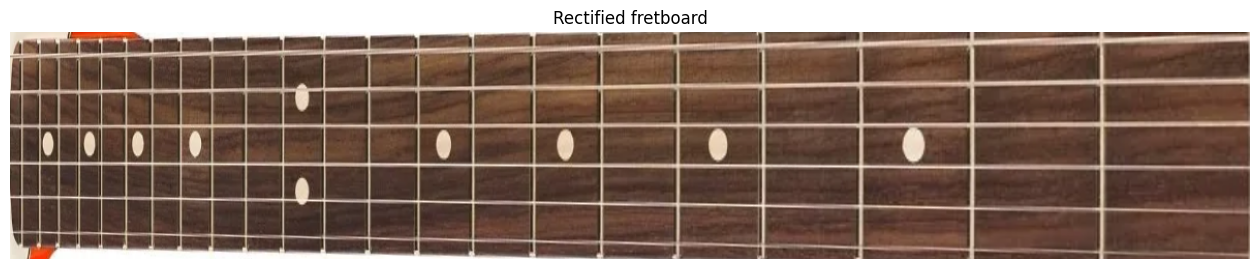

In [10]:

WARP_W = 1200
WARP_H = 220

dst_quad = np.array([
    [0, 0],
    [WARP_W - 1, 0],
    [WARP_W - 1, WARP_H - 1],
    [0, WARP_H - 1],
], dtype=np.float32)

M_roi_to_warp = cv2.getPerspectiveTransform(quad_roi, dst_quad)
M_warp_to_roi = np.linalg.inv(M_roi_to_warp)

warp = cv2.warpPerspective(roi, M_roi_to_warp, (WARP_W, WARP_H))

plt.figure(figsize=(16, 3))
plt.imshow(cv2.cvtColor(warp, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Rectified fretboard")
plt.show()


Detected fret centers (rectified): 21
[  27.    47.    67.    88.   112.   137.5  165.   194.   228.   264.
  304.   347.   395.   447.5  506.5  572.5  648.   727.   823.   931.
 1056.5]


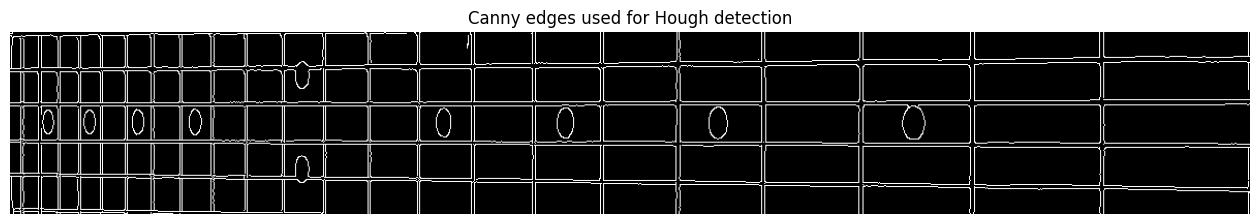

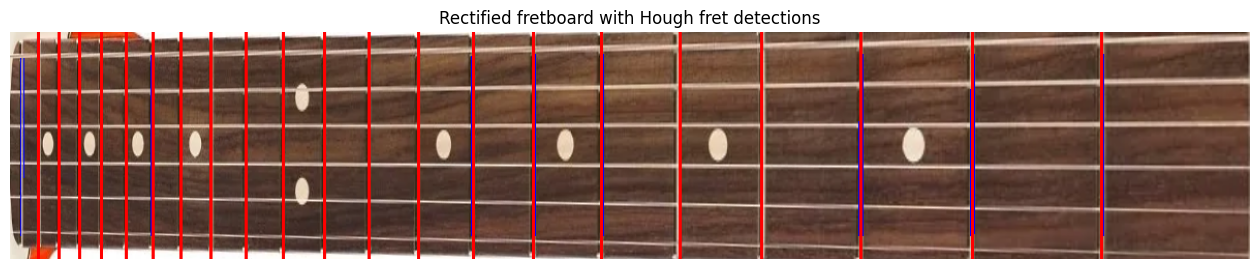

In [11]:

def cluster_positions(xs, gap=8):
    xs = sorted(float(x) for x in xs)
    if not xs:
        return []

    groups = [[xs[0]]]
    for x in xs[1:]:
        if x - groups[-1][-1] <= gap:
            groups[-1].append(x)
        else:
            groups.append([x])

    return [float(np.mean(g)) for g in groups]


def detect_fret_lines_hough_in_rectified(warp_bgr, x_margin_frac=0.02, right_cut_frac=0.92):
    Hh, Ww = warp_bgr.shape[:2]
    gray = cv2.cvtColor(warp_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3, 3), 0)

    y0 = int(round(Hh * 0.10))
    y1 = int(round(Hh * 0.90))
    band = blur[y0:y1, :]

    edges = cv2.Canny(band, 80, 180, apertureSize=3)

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=45,
        minLineLength=int((y1 - y0) * 0.55),
        maxLineGap=8,
    )

    raw_lines = []
    if lines is not None:
        for line in lines[:, 0]:
            x1, yy1, x2, yy2 = map(int, line)
            dx = abs(x2 - x1)
            dy = abs(yy2 - yy1)

            if dy < int((y1 - y0) * 0.45):
                continue
            if dx > 8:
                continue

            xm = 0.5 * (x1 + x2)
            raw_lines.append((xm, yy1 + y0, yy2 + y0))

    centers = cluster_positions([x for x, _, _ in raw_lines], gap=8)

    left_limit = Ww * x_margin_frac
    right_limit = Ww * right_cut_frac
    centers = [x for x in centers if left_limit < x < right_limit]

    line_segments = [((int(round(x)), 0), (int(round(x)), Hh - 1)) for x in centers]
    return edges, raw_lines, centers, line_segments


edges_hough, raw_hough_lines, fret_centers_rectified, fret_lines_rectified = detect_fret_lines_hough_in_rectified(warp)

print("Detected fret centers (rectified):", len(fret_centers_rectified))
print(np.round(fret_centers_rectified, 1))

plt.figure(figsize=(16, 3))
plt.imshow(edges_hough, cmap="gray")
plt.axis("off")
plt.title("Canny edges used for Hough detection")
plt.show()

warp_hough_vis = warp.copy()
for x, y1, y2 in raw_hough_lines:
    cv2.line(warp_hough_vis, (int(round(x)), y1), (int(round(x)), y2), (255, 0, 0), 1)
for x in fret_centers_rectified:
    cv2.line(warp_hough_vis, (int(round(x)), 0), (int(round(x)), WARP_H - 1), (0, 0, 255), 2)

plt.figure(figsize=(16, 3))
plt.imshow(cv2.cvtColor(warp_hough_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Rectified fretboard with Hough fret detections")
plt.show()


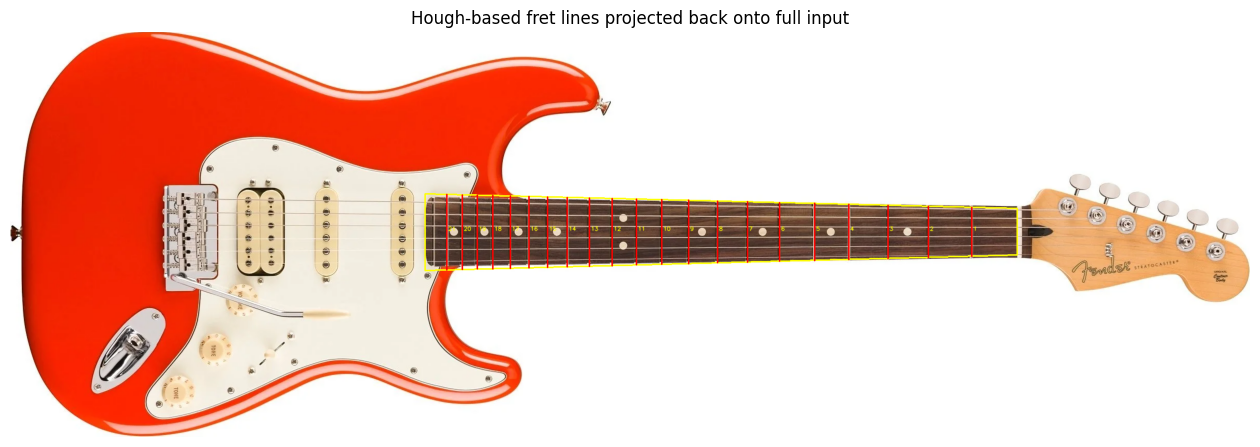

In [13]:
def project_rectified_lines_back_to_full_image(rectified_lines, M_warp_to_roi, x0, y0):
    out = []
    for (p1, p2) in rectified_lines:
        a = np.array([p1[0], p1[1], 1.0], dtype=np.float32)
        b = np.array([p2[0], p2[1], 1.0], dtype=np.float32)

        qa = M_warp_to_roi @ a
        qb = M_warp_to_roi @ b
        qa /= qa[2]
        qb /= qb[2]

        full_a = (int(round(qa[0] + x0)), int(round(qa[1] + y0)))
        full_b = (int(round(qb[0] + x0)), int(round(qb[1] + y0)))
        out.append((full_a, full_b))
    return out


fret_lines_full = project_rectified_lines_back_to_full_image(fret_lines_rectified, M_warp_to_roi, x0, y0)

full_vis = inp.copy()
cv2.polylines(full_vis, [np.round(quad_roi + np.array([x0, y0], dtype=np.float32)).astype(np.int32).reshape(-1, 1, 2)], True, (0, 255, 255), 2)

n_frets = len(fret_lines_full)

for i, (p1, p2) in enumerate(fret_lines_full, start=1):
    cv2.line(full_vis, p1, p2, (0, 0, 255), 2)
    mx = int(round((p1[0] + p2[0]) / 2))
    my = int(round((p1[1] + p2[1]) / 2))
    label = str(n_frets - i + 1)
    cv2.putText(full_vis, label, (mx + 3, my - 3),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 255, 255), 1, cv2.LINE_AA)

plt.figure(figsize=(16, 6))
plt.imshow(cv2.cvtColor(full_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Hough-based fret lines projected back onto full input")
plt.show()